Paradigmatic example of an open quantum battery (OQB): a two-level atom, living in an Hilbert space $\mathcal{H}$ with dimension $dim(\mathcal{H}) = 2$, characterized by an Hamiltonian

$$ \hat{H_0} = (\omega_0 / 2) (\hat{\sigma_z} + 1) \text{.} $$

The atom's eigenstates are the ground state $\ket{0} = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$ and the first excited state $\ket{1} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$, respectively with eigenvalues $0$ and $\omega_0$.

The system is driven by a resonant classical field of intensity $\alpha$ which acts as charger, described by an Hamiltonian $\hat{H}_s(t) = \alpha \hat{\sigma_x}$ that rules the evolution of the system, and spontaneously emitting photons with rate $\kappa$, according to the jump operator $\hat{c} = \sqrt{\kappa} \sigma_-$.

Our purpose is to reproduce the results on https://arxiv.org/abs/2302.12279.

Let us start considering the situation in which the system is initially prepared in the ground state $\ket{0}$ with $\alpha / \kappa = 1$. We solve the unconditional dynamics numerically, computing the evolution of the ergotropy and the energy; then we compute the daemonic evolution of the ergotropy for different unravellings with detection efficiency $\eta = 0.4$:
- A photo-detection.
- An homodyne measure with $\phi = 0°$.
- An homodyne measure with $\phi = 90°$.
- An heterodyne measure.

### Continous photo-detection

$$
\dot\rho = - i [ \hat{H}_s, \rho ] + (1-\eta) \, \mathcal{D}[\hat{c}] \rho + \frac{\eta}{2} \mathcal{H}[\hat{c}^{\dagger} \hat{c}] \rho + \left( \frac{\hat{c}^{\dagger} \rho \hat{c}}{\langle \hat{c}^{\dagger} \hat{c} \rangle}_t - \rho \right) dN_t
$$

The first two terms describe the deterministic evolution, while the last two give the stochastic evolution.

In QuTiP, the Monte Carlo solver can solve this equation when the deterministic part is passed as a Liouvillian.

The Liouvillian superoperator $\mathcal{L}$ defined as

$$ \mathcal{L} \rho = - i [ \hat{H}, \rho ] + \sum_i \mathcal{D}[\hat{c}_i]\rho \text{,} $$

for $\hat{H}$ Hermitian and a set $\{c_i\}$ of collapse operators.

### Homodyne detection

Homodyne measurement performs a measure of the operator $\hat{x}_\theta = \hat{a}e^{i \phi} + \hat{a}^{\dagger}e^{- i \phi}$ and the corresponding stochastic master equation (SME) is

$$
\dot\rho = - i [ \hat{H}_s, \rho ] + \mathcal{D}[\hat{c}] \rho + \sqrt\kappa \mathcal{H}[\hat{c}e^{i \phi}] \rho \, dW_t \text{,}
$$

with *photo-current*

$$
dy_t = \sqrt{\eta} \langle \hat{c}e^{i \phi} + \hat{c}^{\dagger}e^{- i \phi} \rangle dt + dW_t \text{.}
$$

The first two terms of the above SME gives the determistic evolution, while the last term the stochastic one.

In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

t_f = None
dt = None
NUMBER_OF_TRAJECTORIES = None

with open("input.dat", "r") as f:
    # cycle on every line of the file
    for line in f:
        # words separated by a space within a line become the elements of a list
        parts = line.split()
        # it skips empty lines, controls that there are exactly two elements per line (otherwise it skips the line) and skip the comments
        if not line or len(parts) != 2 or line.startswith("#"):
            continue
        key, value = parts      
        if key == "FINALT":
            t_f = float(value)
        elif key == "dt":
            dt = float(value)
        elif key == "NTRAJ":
            NUMBER_OF_TRAJECTORIES = int(value)

NUMBER_OF_TIMEINTERVALS = int(t_f / dt) # number of time intervals
resultsdir = "results/"                 # results directory

Results for a system prepared in an initial pure state with $\alpha / \kappa = 1$ and $\eta = 0.4$.

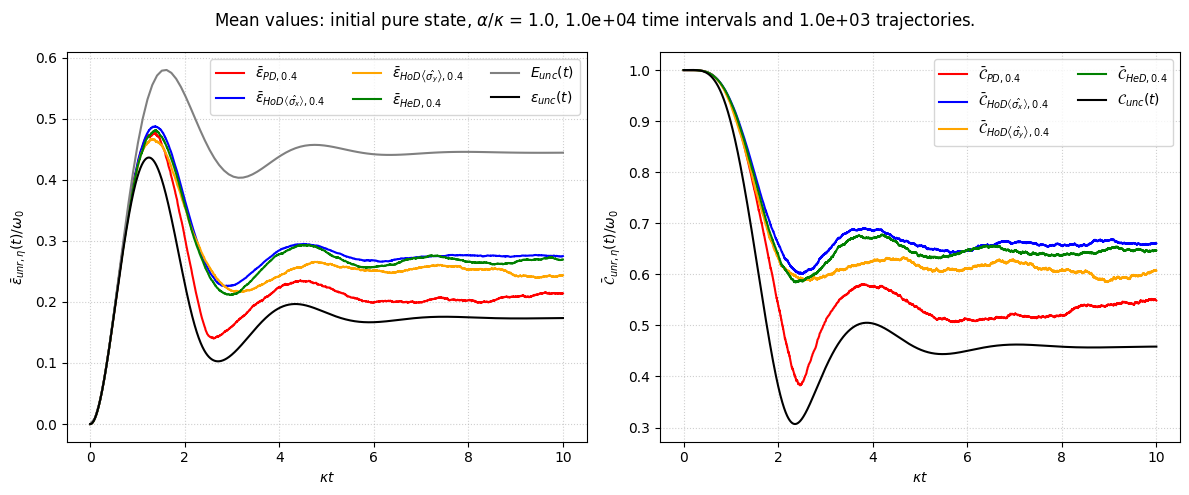

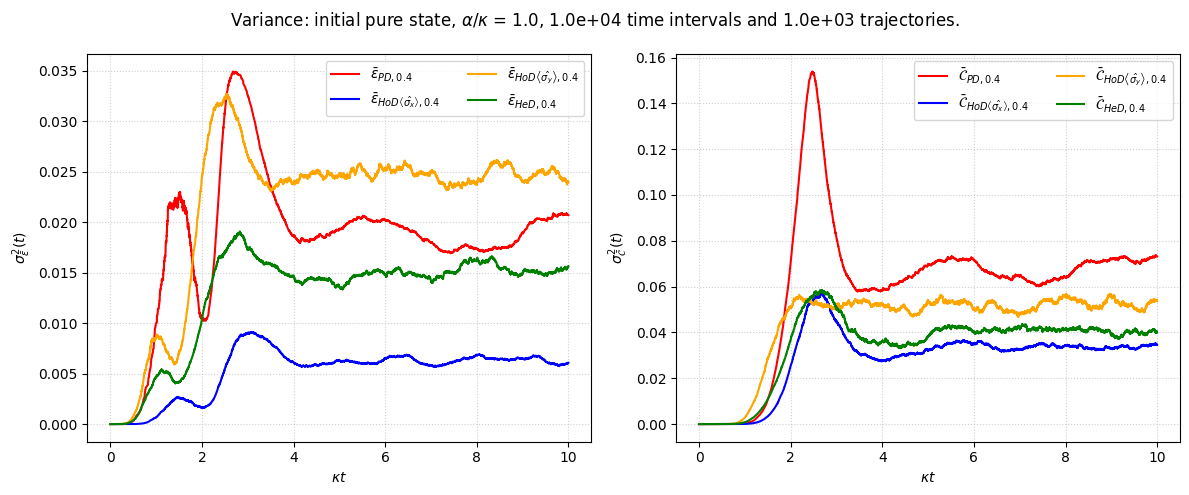

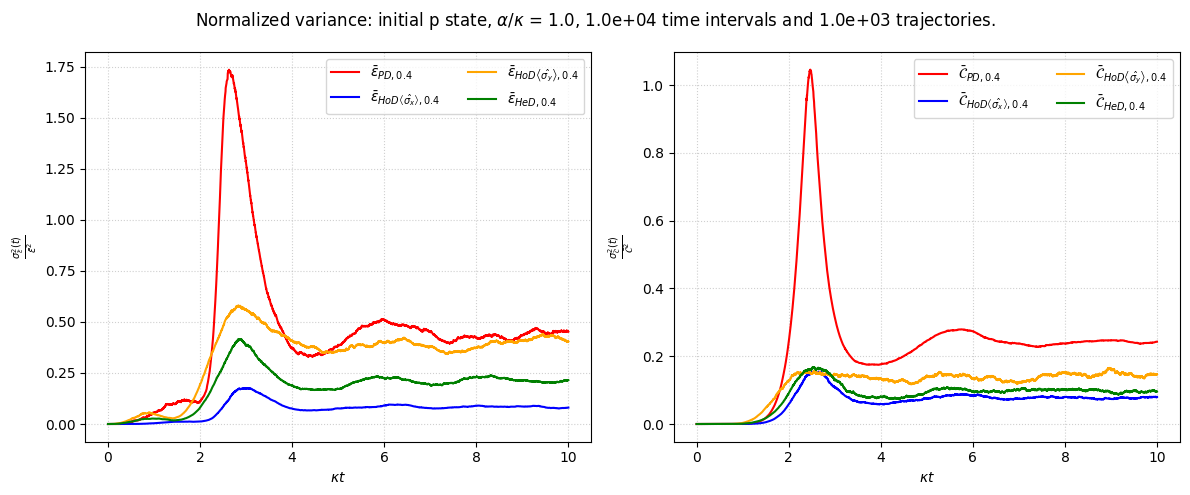

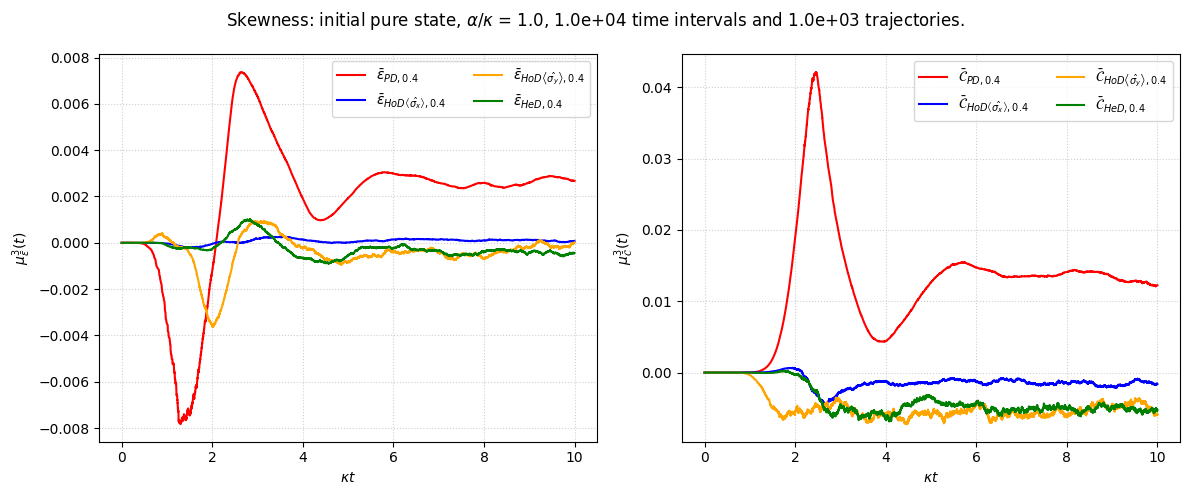

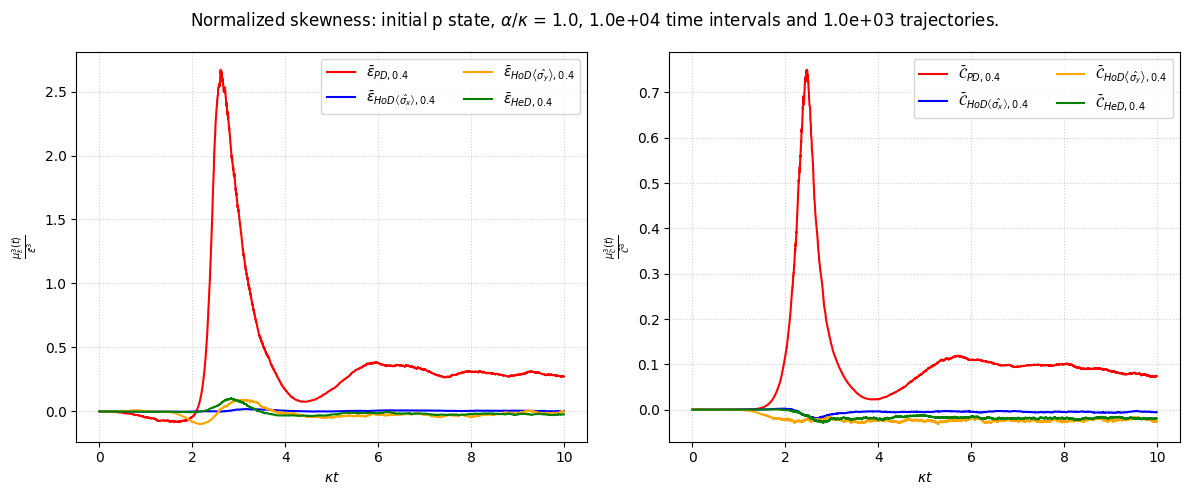

In [2]:
# simulation parameters
alpha_over_kappa = 1.0
eta = 0.4
instate = "p"           # initial state ('p' for pure state, 'm' for maximally mixed)

# labels
unr = ["pd", "hod0", "hod90", "hed"]                    # unravellings
unr_colors = ["red", "blue", "orange", "green"]         # colors for the unravellings
obs = ["erg", "cap"]                                    # observables
obs_labels = [r"\bar{\epsilon}", r"\bar{\mathcal{C}}"]                                                  # observable labels
unr_labels = ["PD", r"HoD \left< \hat{\sigma_x} \right>", r"HoD \left< \hat{\sigma_y} \right>", "HeD"]  # unravelling labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

data = []
data = np.loadtxt(resultsdir + "en_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "gray", label = r"$E_{unc}(t)$")
data = []
data = np.loadtxt(resultsdir + "erg_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "black", label = r"$\epsilon_{unc}(t)$")
data = []
data = np.loadtxt(resultsdir + "cap_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax2.plot(data[:,0], data[:,1], color = "black", label = r"$\mathcal{C}_{unc}(t)$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$" + obs_labels[i] + r"_{unr, \eta} (t) / \omega_0$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

# costrumize legends, y-axis labels
ax1.legend(loc = "upper right", ncol = 3)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Mean values: initial pure state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\sigma^2_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Variance: initial pure state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        var = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        var = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_var = []
        tlist = []
        for x, y in zip(mean, var):
            if x[1] != 0:
                tlist.append(x[0])
                norm_var.append(y[1] / (x[1]**2))
        axs[i].plot(tlist, norm_var, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\sigma^2_" + obs_labels[i] + " (t)}{" +  obs_labels[i] + "^2}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\mu^3_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Skewness: initial pure state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        skw = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        skw = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_skw = []
        tlist = []
        for x, y in zip(mean, skw):
            if x[1] != 0:
                tlist.append(x[0])
                norm_skw.append(y[1] / (x[1]**3))
        axs[i].plot(tlist, norm_skw, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\mu^3_" + obs_labels[i] + " (t)}{" + obs_labels[i] + "^3}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized skewness: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()


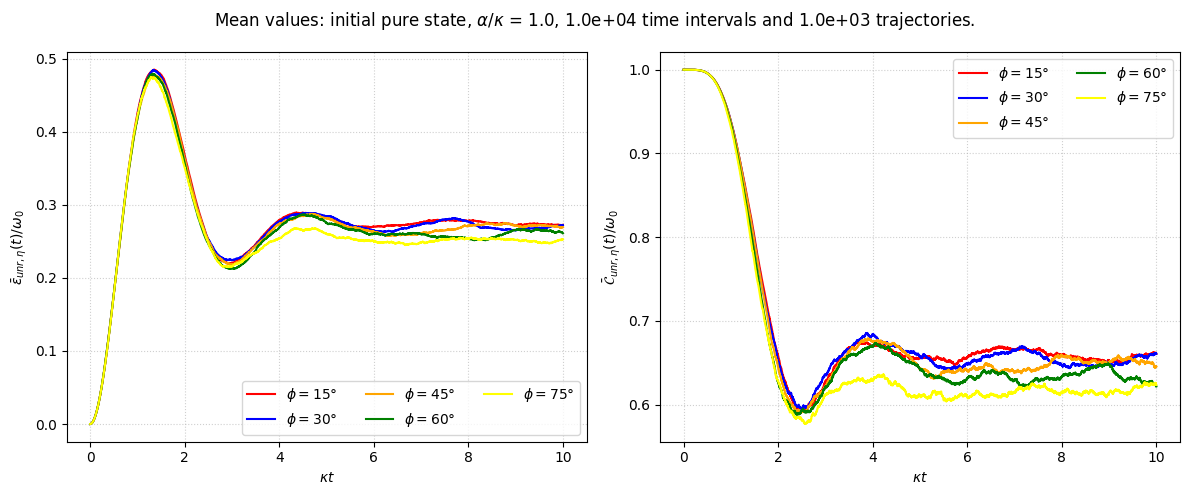

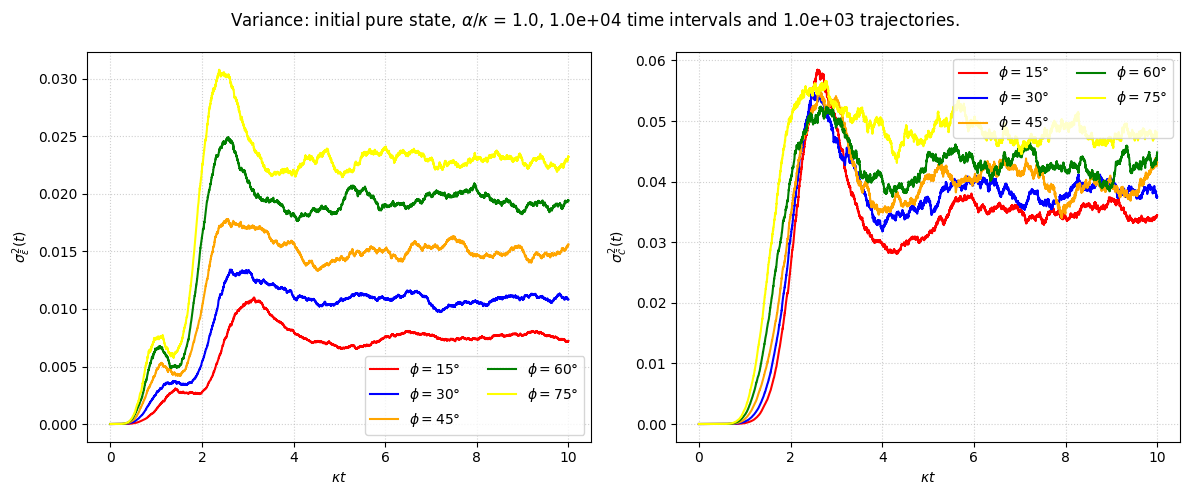

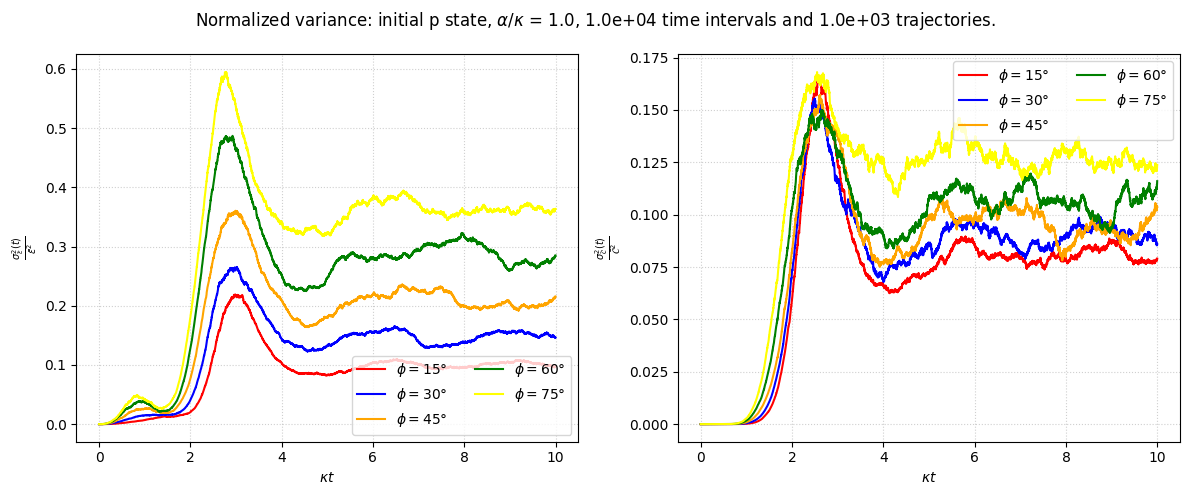

In [ ]:
alpha_over_kappa = 1.0
eta = 0.4
instate = "p"           # initial state ('p' for pure state, 'm' for maximally mixed)

# labels
unr = ["hod15", "hod30", "hod45", "hod60", "hod75"]         # unravellings
unr_colors = ["red", "blue", "orange", "green", "yellow"]   # colors for the unravellings
obs = ["erg", "cap"]                                        # observables
obs_labels = [r"\bar{\epsilon}", r"\bar{\mathcal{C}}"]                                              # observable labels
unr_labels = [r"$\phi = 15°$", r"$\phi = 30°$", r"$\phi = 45°$", r"$\phi = 60°$", r"$\phi = 75°$"]  # unravelling labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = unr_labels[j])

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$" + obs_labels[i] + r"_{unr, \eta} (t) / \omega_0$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

# costrumize legends, y-axis labels
ax1.legend(loc = "lower right", ncol = 3)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Mean values: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = unr_labels[j])

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\sigma^2_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "lower right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        var = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        var = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_var = []
        tlist = []
        for x, y in zip(mean, var):
            if x[1] != 0:
                tlist.append(x[0])
                norm_var.append(y[1] / (x[1]**2))
        axs[i].plot(tlist, norm_var, color = unr_colors[j], label = unr_labels[j])

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\sigma^2_" + obs_labels[i] + " (t)}{" +  obs_labels[i] + "^2}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "lower right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()


Initial pure state, with $\alpha/\kappa = 0.4$ and $\eta = 1.0$.

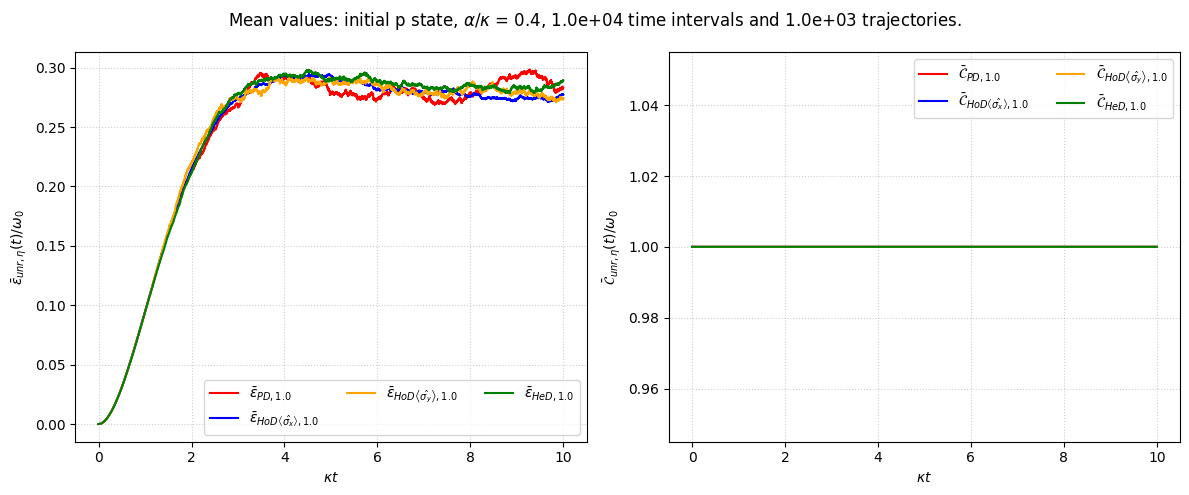

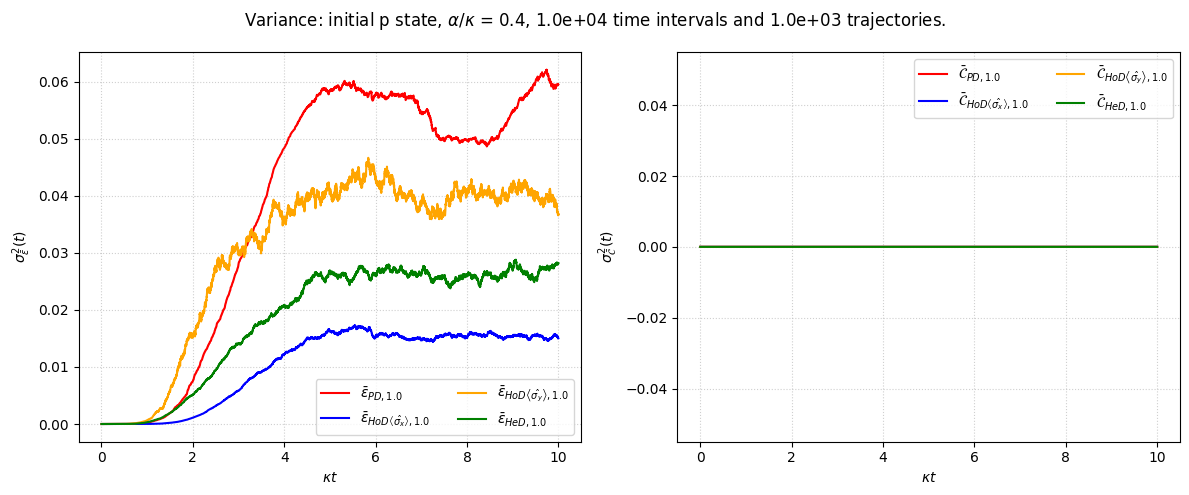

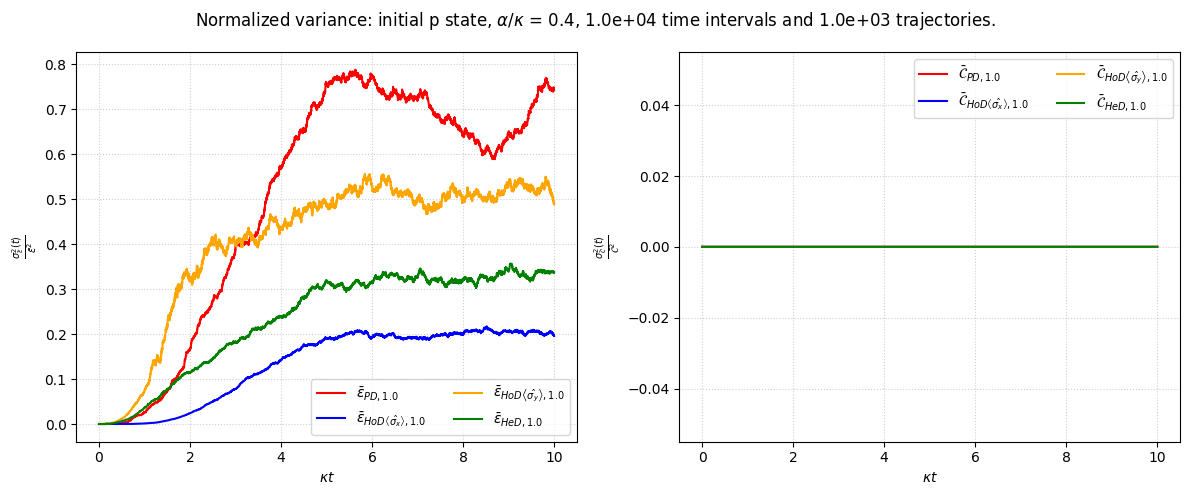

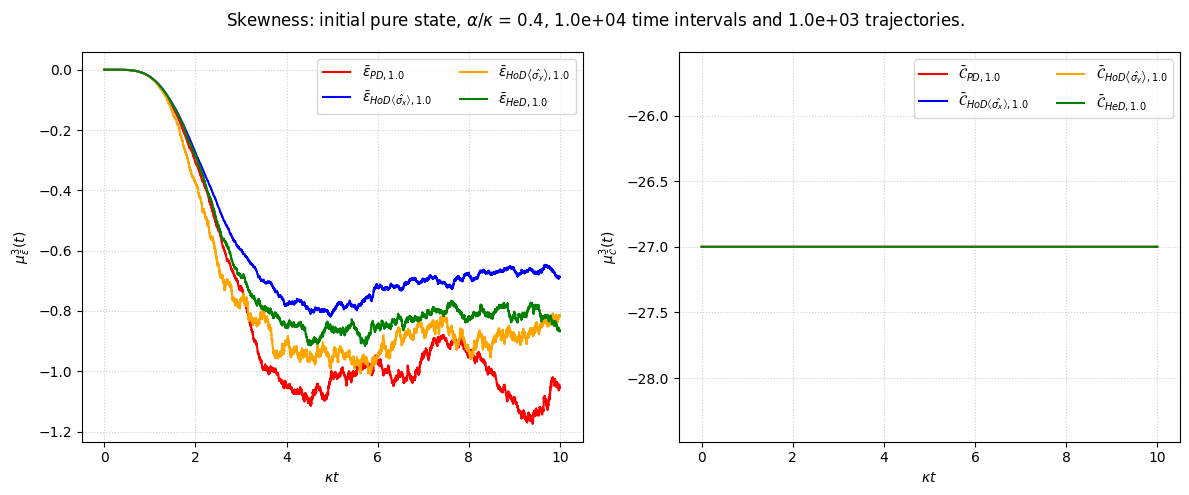

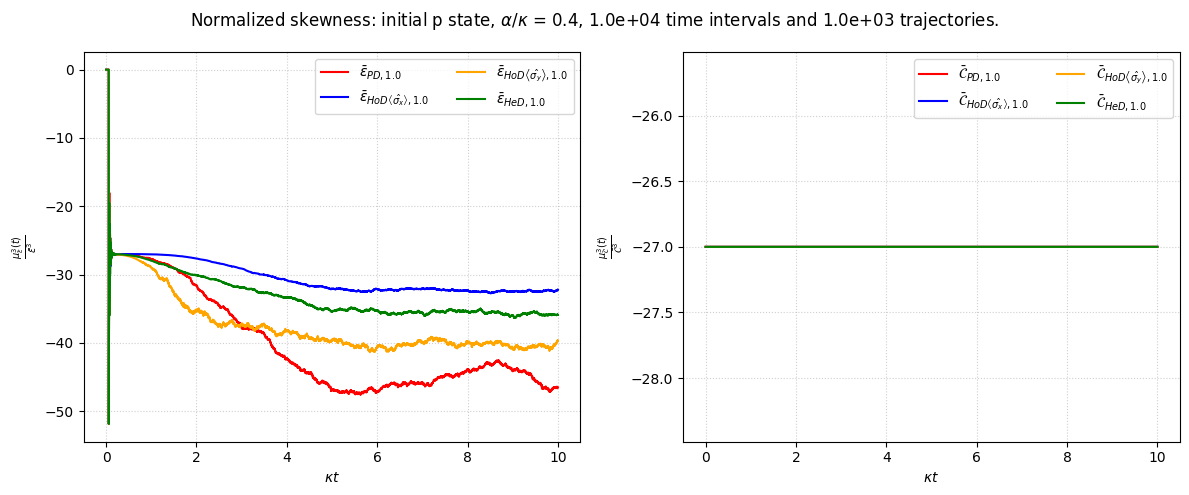

In [4]:
alpha_over_kappa = 0.4
eta = 1.0
instate = "p"           # initial state ('p' for pure state, 'm' for maximally mixed)

# labels
unr = ["pd", "hod0", "hod90", "hed"]                    # unravellings
unr_colors = ["red", "blue", "orange", "green"]         # colors for the unravellings
obs = ["erg", "cap"]                                    # observables
obs_labels = [r"\bar{\epsilon}", r"\bar{\mathcal{C}}"]                                                  # observable labels
unr_labels = ["PD", r"HoD \left< \hat{\sigma_x} \right>", r"HoD \left< \hat{\sigma_y} \right>", "HeD"]  # unravelling labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$" + obs_labels[i] + r"_{unr, \eta} (t) / \omega_0$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

# costrumize legends, y-axis labels
ax1.legend(loc = "lower right", ncol = 3)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Mean values: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\sigma^2_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "lower right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        var = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        var = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_var = []
        tlist = []
        for x, y in zip(mean, var):
            if x[1] != 0:
                tlist.append(x[0])
                norm_var.append(y[1] / (x[1]**2))
        axs[i].plot(tlist, norm_var, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\sigma^2_" + obs_labels[i] + " (t)}{" +  obs_labels[i] + "^2}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "lower right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\mu^3_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Skewness: initial pure state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        skw = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        skw = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_skw = []
        tlist = []
        for x, y in zip(mean, skw):
            if x[1] != 0:
                tlist.append(x[0])
                norm_skw.append(y[1] / (x[1]**3))
        axs[i].plot(tlist, norm_skw, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\mu^3_" + obs_labels[i] + " (t)}{" + obs_labels[i] + "^3}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized skewness: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()



We now consider the different scenario of a system initially prepared in a mixed state with $\alpha / \kappa = 0.4$. We first compute the evolution of the unconditional energy and ergotropy, comparing the cases of an initial pure state and an initial mixed state. Then we perform different unravellings with unit efficiency $\eta = 1$ with mixed initial states.

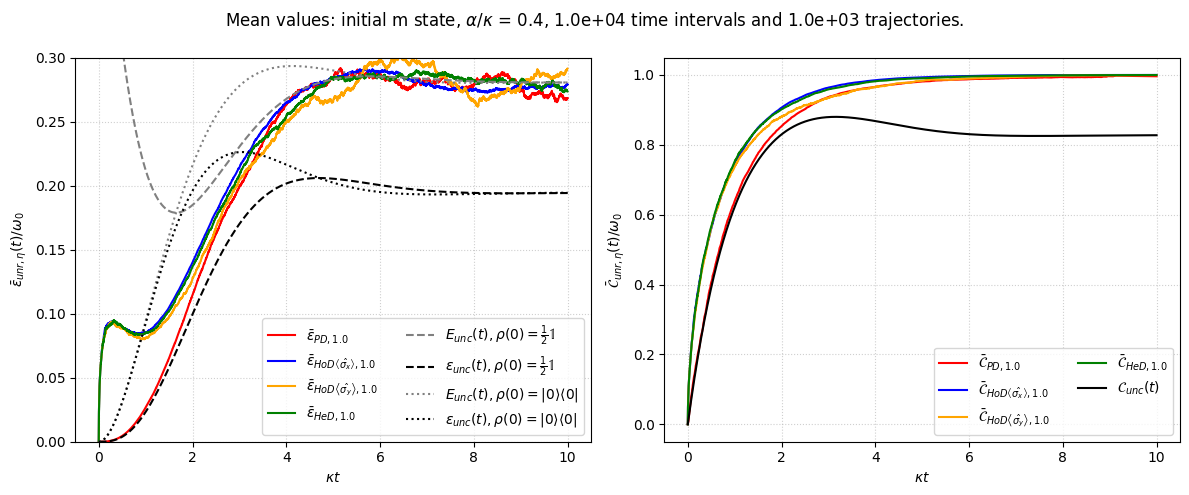

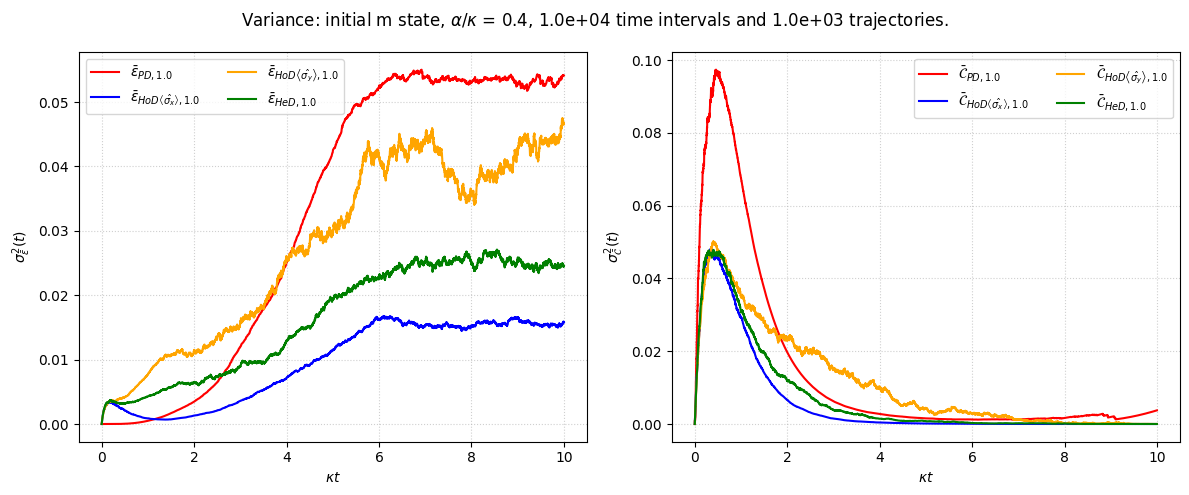

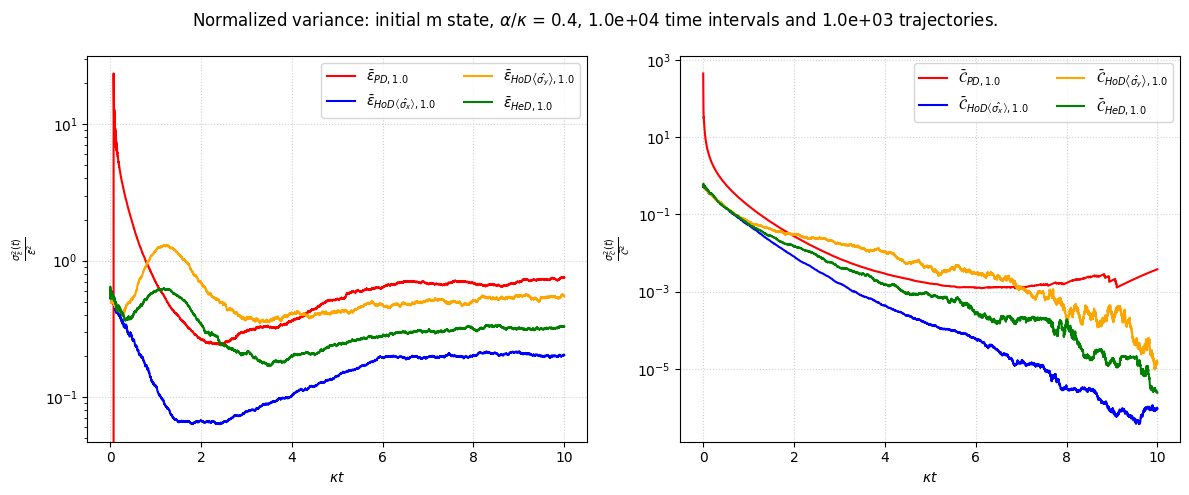

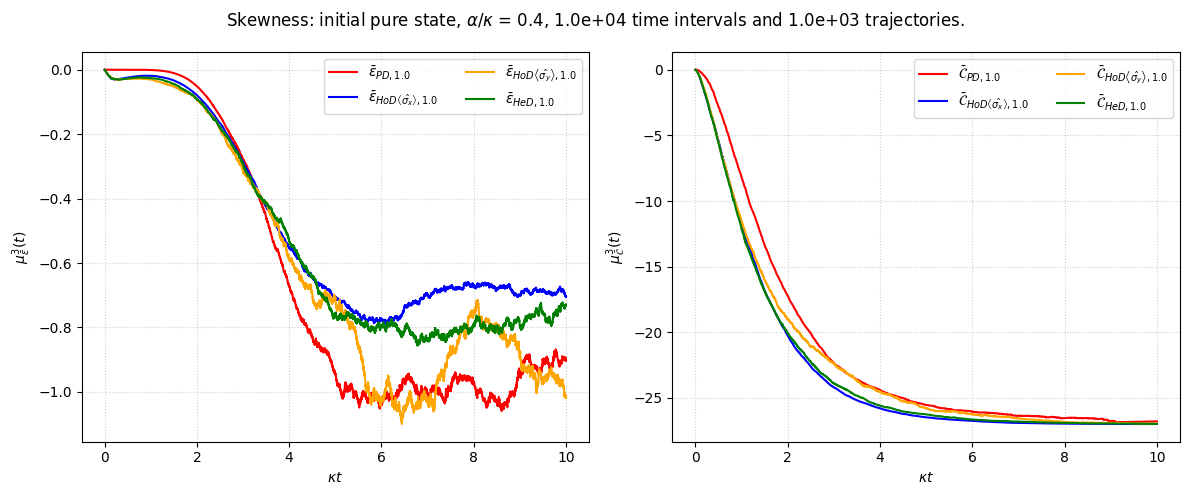

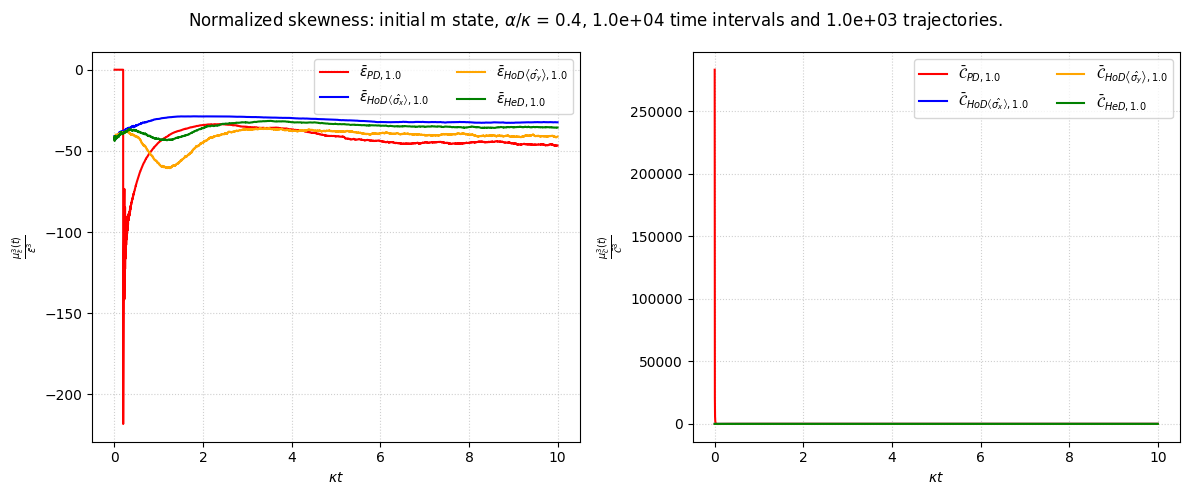

In [5]:
alpha_over_kappa = 0.4
eta = 1.0
instate = "m"           # initial state ('p' for pure state, 'm' for maximally mixed)

# labels
unr = ["pd", "hod0", "hod90", "hed"]                    # unravellings
unr_colors = ["red", "blue", "orange", "green"]         # colors for the unravellings
obs = ["erg", "cap"]                                    # observables
obs_labels = [r"\bar{\epsilon}", r"\bar{\mathcal{C}}"]                                                  # observable labels
unr_labels = ["PD", r"HoD \left< \hat{\sigma_x} \right>", r"HoD \left< \hat{\sigma_y} \right>", "HeD"]  # unravelling labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

data = []
data = np.loadtxt(resultsdir + "en_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "gray", linestyle = "--", label = r"$E_{unc}(t), \rho(0) = \frac{1}{2} \mathbb{1}$")
data = []
data = np.loadtxt(resultsdir + "erg_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "black", linestyle = "--", label = r"$\epsilon_{unc}(t), \rho(0) = \frac{1}{2} \mathbb{1}$")
data = []
data = np.loadtxt(resultsdir + "en_unc_p_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "gray", linestyle = ":", label = r"$E_{unc}(t), \rho(0) = \vert 0 \rangle \langle 0 \vert$")
data = []
data = np.loadtxt(resultsdir + "erg_unc_p_alpha" + str(alpha_over_kappa) + ".dat")
ax1.plot(data[:,0], data[:,1], color = "black", linestyle = ":", label = r"$\epsilon_{unc}(t), \rho(0) = \vert 0 \rangle \langle 0 \vert$")
data = []
data = np.loadtxt(resultsdir + "cap_unc_" + instate + "_alpha" + str(alpha_over_kappa) + ".dat")
ax2.plot(data[:,0], data[:,1], color = "black", label = r"$\mathcal{C}_{unc}(t)$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$" + obs_labels[i] + r"_{unr, \eta} (t) / \omega_0$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.set_ylim(0, 0.3)

# costrumize legends, y-axis labels
ax1.legend(loc = "lower right", ncol = 2)
ax2.legend(loc = "lower right", ncol = 2)

fig.suptitle(
        f"Mean values: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\sigma^2_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper left", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        var = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        var = np.loadtxt(resultsdir + "var_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_var = []
        tlist = []
        for x, y in zip(mean, var):
            if x[1] != 0:
                tlist.append(x[0])
                norm_var.append(y[1] / (x[1]**2))
        axs[i].plot(tlist, norm_var, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\sigma^2_" + obs_labels[i] + " (t)}{" +  obs_labels[i] + "^2}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)
    axs[i].set_yscale("log")

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized variance: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        data = []
        data = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        axs[i].plot(data[:,0], data[:,1], color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\mu^3_" + obs_labels[i] + " (t)$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Skewness: initial pure state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()

# normalized skewness

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
axs = [ax1, ax2]

for i in range(len(axs)):
    for j in range(len(unr)):
        mean = []
        skw = []
        mean = np.loadtxt(resultsdir + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        skw = np.loadtxt(resultsdir + "skw_" + obs[i] + "_" + unr[j] + "_" + instate + "_eta" + str(eta) + "_alpha" + str(alpha_over_kappa) + ".dat", delimiter="\t")
        norm_skw = []
        tlist = []
        for x, y in zip(mean, skw):
            if x[1] != 0:
                tlist.append(x[0])
                norm_skw.append(y[1] / (x[1]**3))
        axs[i].plot(tlist, norm_skw, color = unr_colors[j], label = r"$" + obs_labels[i] + r"_{" + unr_labels[j] + ", " + str(eta) + r"}$")

# costumize axes and grids
for i in range(len(axs)):
    axs[i].set_xlabel(r"$\kappa t$")
    axs[i].set_ylabel(r"$\frac{\mu^3_" + obs_labels[i] + " (t)}{" + obs_labels[i] + "^3}$")
    axs[i].grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "upper right", ncol = 2)
ax2.legend(loc = "upper right", ncol = 2)

fig.suptitle(
        f"Normalized skewness: initial " + instate + " state, "  r"$\alpha / \kappa$" f" = {alpha_over_kappa}," f"{NUMBER_OF_TIMEINTERVALS : .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()


In conclusion we focus on the steady-state (SS) properties of the system, evaluating the stationary daemonic ergotropies for different unravellings with different efficiencies ($\eta = 0.1$ and $\eta = 0.7$) as a function of $\alpha / \kappa$ and comparing them with the SS energy and ergotropy of the unconditional dynamics. 

### Unconditional SS energy and ergotropy

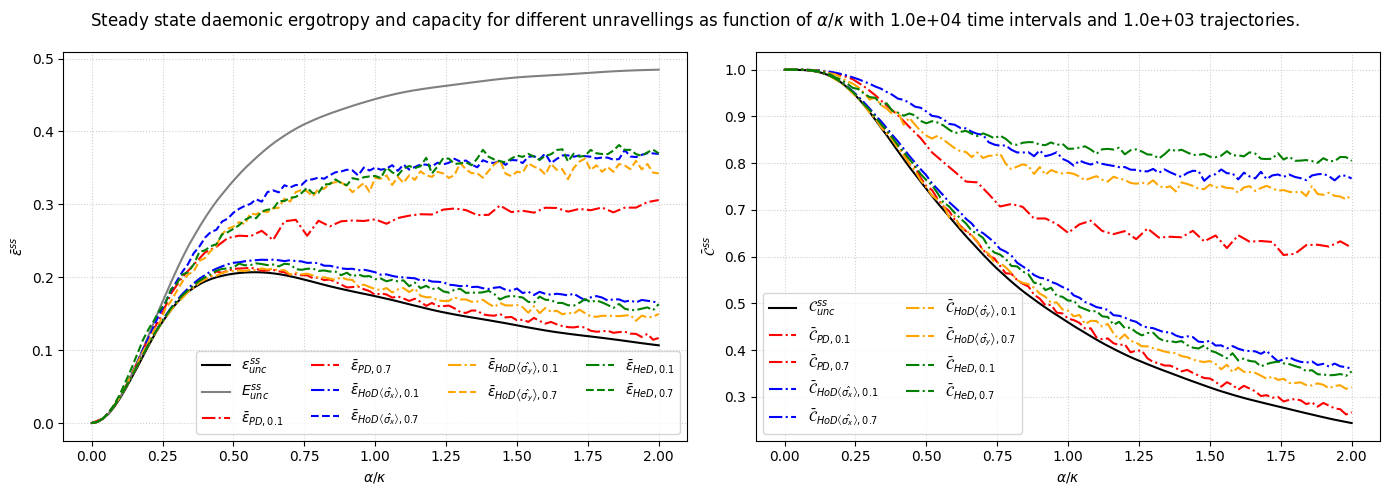

In [8]:
alpha_over_kappa = 0.4
eta = 1.0

ss_en_unc = np.loadtxt("results/ss_en_unc.dat")
ss_erg_unc = np.loadtxt("results/ss_erg_unc.dat")
ss_erg_pd_eta01 = np.loadtxt("results/ss_erg_pd_eta0.1.dat")
ss_erg_pd_eta07 = np.loadtxt("results/ss_erg_pd_eta0.7.dat")
ss_erg_hod0_eta01 = np.loadtxt("results/ss_erg_hod0_eta0.1.dat")
ss_erg_hod0_eta07 = np.loadtxt("results/ss_erg_hod0_eta0.7.dat")
ss_erg_hod90_eta01 = np.loadtxt("results/ss_erg_hod90_eta0.1.dat")
ss_erg_hod90_eta07 = np.loadtxt("results/ss_erg_hod90_eta0.7.dat")
ss_erg_hed_eta01 = np.loadtxt("results/ss_erg_hed_eta0.1.dat")
ss_erg_hed_eta07 = np.loadtxt("results/ss_erg_hed_eta0.7.dat")

ss_cap_unc = np.loadtxt("results/ss_cap_unc.dat")
ss_cap_pd_eta01 = np.loadtxt("results/ss_cap_pd_eta0.1.dat")
ss_cap_pd_eta07 = np.loadtxt("results/ss_cap_pd_eta0.7.dat")
ss_cap_hod0_eta01 = np.loadtxt("results/ss_cap_hod0_eta0.1.dat")
ss_cap_hod0_eta07 = np.loadtxt("results/ss_cap_hod0_eta0.7.dat")
ss_cap_hod90_eta01 = np.loadtxt("results/ss_cap_hod90_eta0.1.dat")
ss_cap_hod90_eta07 = np.loadtxt("results/ss_cap_hod90_eta0.7.dat")
ss_cap_hed_eta01 = np.loadtxt("results/ss_cap_hed_eta0.1.dat")
ss_cap_hed_eta07 = np.loadtxt("results/ss_cap_hed_eta0.7.dat")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# energy and ergotropy for maximally mixed initial state
ax1.plot(ss_erg_unc[:, 0], ss_erg_unc[:, 1], color = 'black', label = r"$\epsilon^{ss}_{unc}$")
ax1.plot(ss_en_unc[:, 0], ss_en_unc[:, 1], color = 'gray', label = r"$E^{ss}_{unc}$")
ax1.plot(ss_erg_pd_eta01[:, 0], ss_erg_pd_eta01[:, 1], color = 'red', linestyle = "-.", label = r"$\bar{\epsilon}_{PD, 0.1}$")
ax1.plot(ss_erg_pd_eta07[:, 0], ss_erg_pd_eta07[:, 1], color = 'red', linestyle = "-.", label = r"$\bar{\epsilon}_{PD, 0.7}$")
ax1.plot(ss_erg_hod0_eta01[:, 0], ss_erg_hod0_eta01[:, 1], color = 'blue', linestyle = "-.", label = r"$\bar{\epsilon}_{HoD \left< \hat{\sigma_x} \right>, 0.1}$")
ax1.plot(ss_erg_hod0_eta07[:, 0], ss_erg_hod0_eta07[:, 1], color = 'blue', linestyle = "--", label = r"$\bar{\epsilon}_{HoD \left< \hat{\sigma_x} \right>, 0.7}$")
ax1.plot(ss_erg_hod90_eta01[:, 0], ss_erg_hod90_eta01[:, 1], color = 'orange', linestyle = "-.", label = r"$\bar{\epsilon}_{HoD \left< \hat{\sigma_y} \right>, 0.1}$")
ax1.plot(ss_erg_hod90_eta07[:, 0], ss_erg_hod90_eta07[:, 1], color = 'orange', linestyle = "--", label = r"$\bar{\epsilon}_{HoD \left< \hat{\sigma_y} \right>, 0.7}$")
ax1.plot(ss_erg_hed_eta01[:, 0], ss_erg_hed_eta01[:, 1], color = 'green', linestyle = "-.", label = r"$\bar{\epsilon}_{HeD, 0.1}$")
ax1.plot(ss_erg_hed_eta07[:, 0], ss_erg_hed_eta07[:, 1], color = 'green', linestyle = "--", label = r"$\bar{\epsilon}_{HeD, 0.7}$")

ax2.plot(ss_cap_unc[:, 0], ss_cap_unc[:, 1], color = 'black', label = r"$\mathcal{C}^{ss}_{unc}$")
ax2.plot(ss_cap_pd_eta01[:, 0], ss_cap_pd_eta01[:, 1], color = 'red', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{PD, 0.1}$")
ax2.plot(ss_cap_pd_eta07[:, 0], ss_cap_pd_eta07[:, 1], color = 'red', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{PD, 0.7}$")
ax2.plot(ss_cap_hod0_eta01[:, 0], ss_cap_hod0_eta01[:, 1], color = 'blue', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HoD \left< \hat{\sigma_x} \right>, 0.1}$")
ax2.plot(ss_cap_hod0_eta07[:, 0], ss_cap_hod0_eta07[:, 1], color = 'blue', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HoD \left< \hat{\sigma_x} \right>, 0.7}$")
ax2.plot(ss_cap_hod90_eta01[:, 0], ss_cap_hod90_eta01[:, 1], color = 'orange', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HoD \left< \hat{\sigma_y} \right>, 0.1}$")
ax2.plot(ss_cap_hod90_eta07[:, 0], ss_cap_hod90_eta07[:, 1], color = 'orange', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HoD \left< \hat{\sigma_y} \right>, 0.7}$")
ax2.plot(ss_cap_hed_eta01[:, 0], ss_cap_hed_eta01[:, 1], color = 'green', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HeD , 0.1}$")
ax2.plot(ss_cap_hed_eta07[:, 0], ss_cap_hed_eta07[:, 1], color = 'green', linestyle = "-.", label = r"$\bar{\mathcal{C}}_{HeD , 0.7}$")

# costumize axes and grids
for ax in (ax1, ax2):
    ax.set_xlabel(r"$\alpha / \kappa$")
    ax.grid(True, linestyle = ':', alpha = 0.6)

ax1.legend(loc = "lower right", ncol = 4)
ax2.legend(loc = "lower left", ncol = 2)
ax1.set_ylabel(r"$\bar{\epsilon}^{ss}$")
ax2.set_ylabel(r"$\bar{\mathcal{C}}^{ss}$")
# ax1.set_yscale("log")

plt.suptitle(
        f"Steady state daemonic ergotropy and capacity for different unravellings as function of " r"$\alpha / \kappa$" f" with{NUMBER_OF_TIMEINTERVALS: .1e} time intervals and{NUMBER_OF_TRAJECTORIES : .1e} trajectories."
    )

# layout optimization and visualization
plt.tight_layout()
plt.show()